<a href="https://colab.research.google.com/github/Varsha11-hub/Diabetes/blob/main/diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

First 5 rows of dataset:
   Pregnancies  Glucose  BloodPressure  ...  DiabetestPedigreeFunction  Age  Outcome
0            6      148             72  ...                      0.627   50        1
1            1       85             66  ...                      0.351   31        0
2            8      183             64  ...                      0.672   32        1
3            1       89             66  ...                      0.167   21        0
4            0      137             40  ...                      2.288   33        1

[5 rows x 9 columns]

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Pregnancies                768 non-null    int64  
 1   Glucose                    768 non-null    int64  
 2   BloodPressure              768 non-null    int64  
 3   SkinThickness              768 n

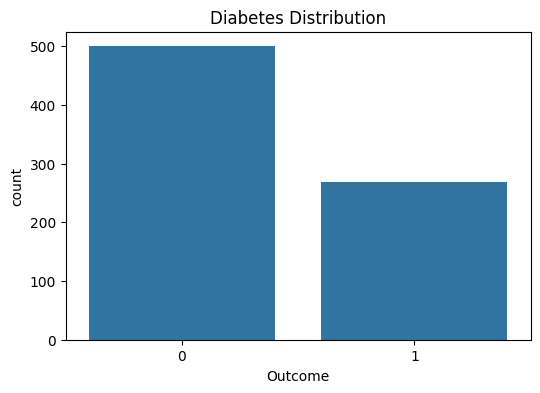


Model Accuracy: 0.7467532467532467

Confusion Matrix:
[[78 21]
 [18 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

url = "/content/diabetes (1).csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetestPedigreeFunction",
    "Age",a
    "Outcome"
]

# Read the CSV, skipping the first row (which is the actual header) and assign custom column names.
df = pd.read_csv(url, names=columns, skiprows=1)

# Convert all columns to numeric types. 'Outcome' should also be numeric for the model.
# Using errors='coerce' will turn non-convertible values into NaN.
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN values if any, as LogisticRegression cannot handle them directly.
# Alternatively, imputation could be used.
df.dropna(inplace=True)

print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Distribution")
plt.show()

X=df.drop("Outcome", axis=1)
Y=df["Outcome"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
    )


model=LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(Y_test,predictions)
print("\nModel Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, predictions))

print("\nClassification Report:")
print(classification_report(Y_test, predictions))